# **LOGISTIC REGRESSION**

**1. Data Exploration:**

a. Load the dataset and perform exploratory data analysis (EDA).

b. Examine the features, their types, and summary statistics.

c. Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.


**Loads important library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load the dataset**

In [2]:
df = pd.read_csv("diabetes.csv")


**Check first and last rows**

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


**Check total rows and columns**

In [5]:
df.shape

(768, 9)

**Check columns detail**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Check statistical information of columns**

In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Check null or missing values**

In [8]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

**Check duplicates**

In [9]:
df.duplicated().sum()

np.int64(0)

**Check data type of each column**

In [10]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

**Univariate analysis:** Univariate analysis is used to understand each variable individually before comparing it with others. it includes histogram, boxplot ect.

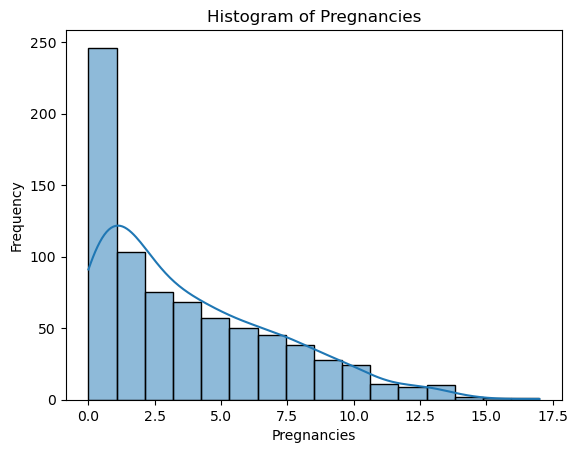

In [11]:
# Histogram of Columns

col = 'Pregnancies'

sns.histplot(df[col], kde=True) # kernal density estimates = true adds smooth curve to plot.
plt.title(f"Histogram of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

**Pregnancies:** Histogram shows that the data is right skewed data and most observation lies under 0 to 4 range. there are some extreme values above 12.

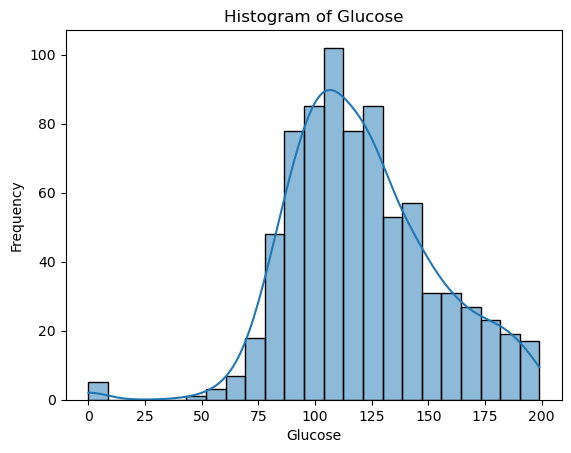

In [12]:
col = 'Glucose'

sns.histplot(df[col], kde=True)
plt.title(f"Histogram of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

**Glucose:** The histogram of the Glucose variable shows a slightly positively skewed distribution. Most observations are concentrated between 90 and 140, with a peak around 100–120. A few high glucose values are observed, and an unusual value near 0 may indicate a potential data issue.

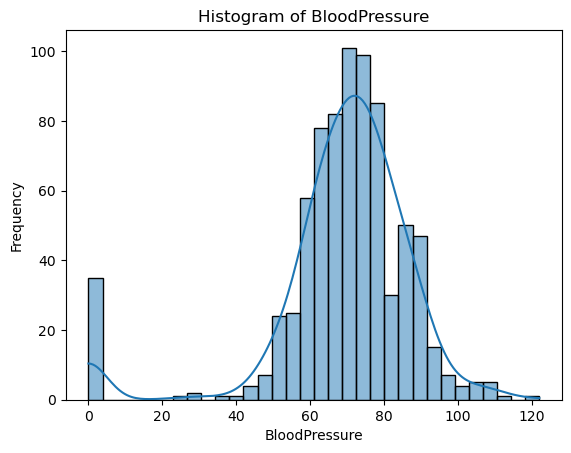

In [13]:
col = 'BloodPressure'

sns.histplot(df[col], kde=True)
plt.title(f"Histogram of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

**BloodPressure:** The histogram of the BloodPressure variable shows an approximately normal distribution centered around 70–75. Most observations fall between 60 and 85. However, zero values are present, which are medically unrealistic and may represent missing data. The variable shows slight positive skewness.

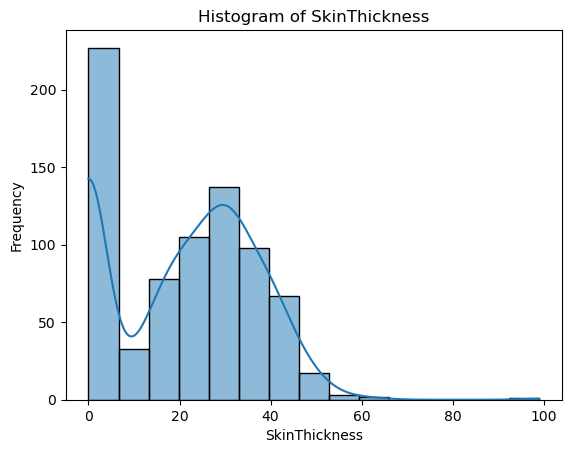

In [14]:
col = 'SkinThickness'

sns.histplot(df[col], kde=True)
plt.title(f"Histogram of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

**SkinThickness:** The histogram of the SkinThickness variable shows a highly positively skewed distribution with a large number of zero values. Since skin thickness cannot be zero, these likely represent missing data. Most valid observations lie between 15 and 40, with a few high outliers present.

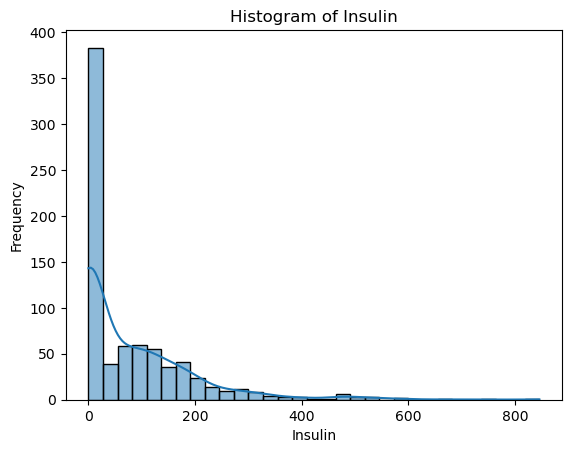

In [15]:
col = 'Insulin'

sns.histplot(df[col], kde=True)
plt.title(f"Histogram of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

**Insulin:** The histogram of the Insulin variable shows a highly positively skewed distribution with a large number of zero values. Since insulin levels cannot be zero, these likely represent missing data. The variable also contains extreme high outliers, with values extending beyond 800. Therefore, data treatment is required before model building.

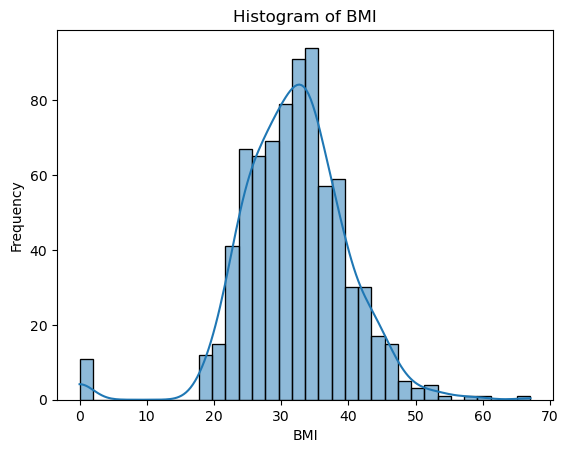

In [16]:
col = 'BMI'

sns.histplot(df[col], kde=True)
plt.title(f"Histogram of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

**BMI:** The histogram of the BMI variable shows an approximately normal distribution with slight positive skewness. Most observations are concentrated between 25 and 40, with a peak around 30–35. However, zero values are present, which are unrealistic and may represent missing data. A few high outliers are also observed.

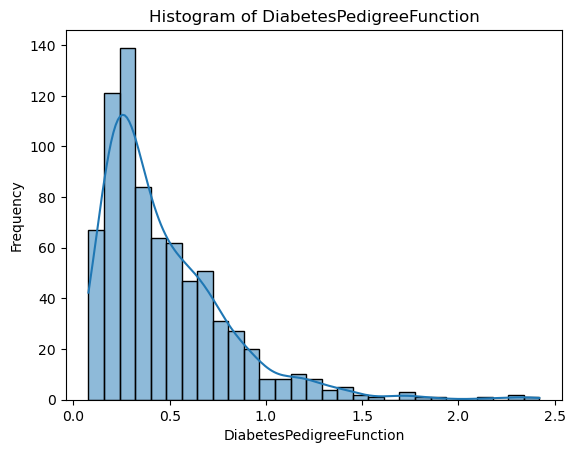

In [17]:
col = 'DiabetesPedigreeFunction'

sns.histplot(df[col], kde=True)
plt.title(f"Histogram of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

**DiabetesPedigreeFunction:** The histogram of the DiabetesPedigreeFunction variable shows a positively skewed distribution. Most observations are concentrated between 0.1 and 0.6, with a peak around 0.2–0.4. A few high values are present, indicating possible outliers. The variable is not normally distributed.

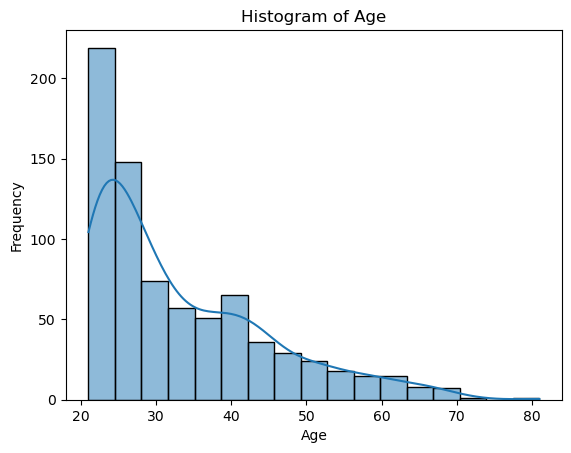

In [18]:
col = 'Age'

sns.histplot(df[col], kde=True)
plt.title(f"Histogram of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

**Age:** The histogram of the Age variable shows a positively skewed distribution. Most observations are concentrated between 20 and 40 years, with a peak around 22–30 years. A few higher age values are present, but these are natural and not data errors. The variable is not normally distributed.

**Boxplots for detecting Outliers**

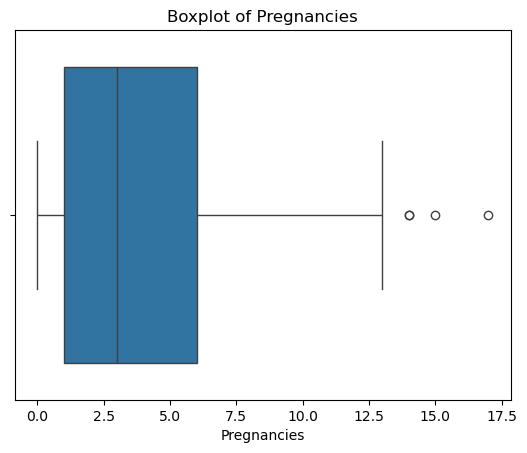

IQR: 5.0


In [19]:
# Checking Outliers for each column
cols = df.select_dtypes(include=np.number).columns

# Boxplot
col='Pregnancies'
sns.boxplot(x=df[col])
plt.title(f"Boxplot of {col}")
plt.show()

# IQR Calculation
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

print("IQR:", IQR)

**Outliers in pregnancies:** Box plot shows that there are 3 outliers present from 14 to 17 pregancies which is very rare but can be medically possible so that's why we will keep it as it is.

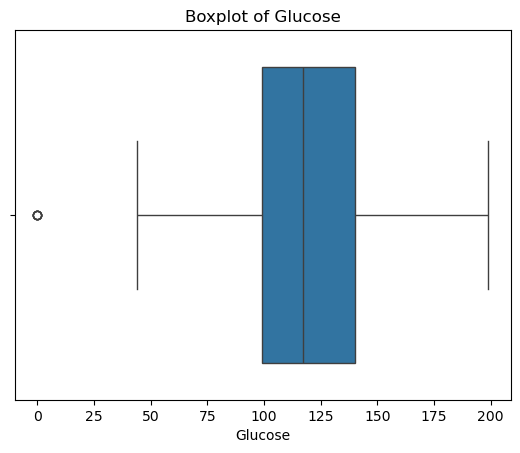

IQR: 41.25


In [20]:
col='Glucose'
sns.boxplot(x=df[col])
plt.title(f"Boxplot of {col}")
plt.show()

# IQR Calculation
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

print("IQR:", IQR)

In [21]:
df=df[df['Glucose']!=0]

In [22]:
len(df)

763

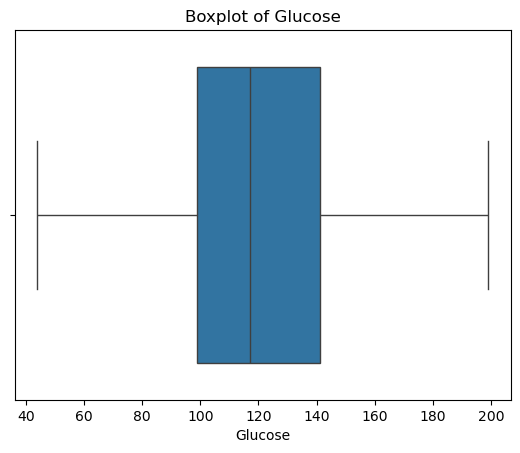

In [23]:
col='Glucose'
sns.boxplot(x=df[col])
plt.title(f"Boxplot of {col}")
plt.show()


**Outliers in Glucose:** Box plot of Glucose shows only 1 outlier where the value of Glucose is 0 so i removed that row because it is a error and medically not possible.

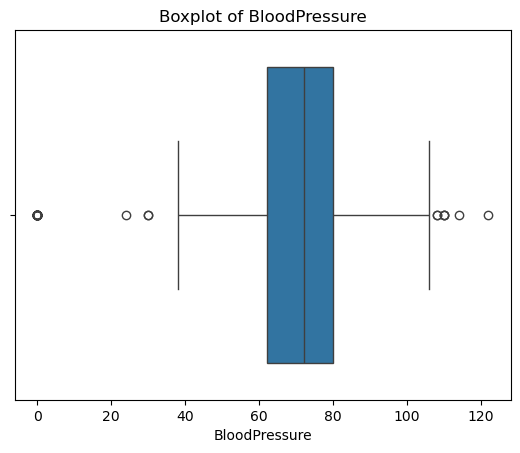

IQR: 18.0


In [24]:
col='BloodPressure'
sns.boxplot(x=df[col])
plt.title(f"Boxplot of {col}")
plt.show()

# IQR Calculation
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

print("IQR:", IQR)

In [25]:
df=df[df['BloodPressure']>=40]

In [26]:
len(df)

724

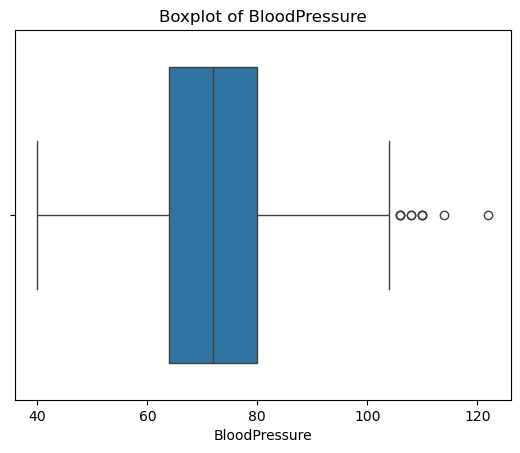

In [27]:
col='BloodPressure'
sns.boxplot(x=df[col])
plt.title(f"Boxplot of {col}")
plt.show()

**Outliers in BloodPressure :** Low Bp outliers are not possible medically so i removed that and high bp range from 105 to 120 can be medically possible so i wll keep it as it is.

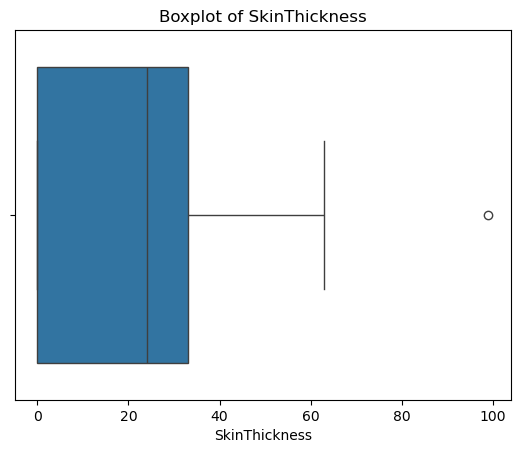

IQR: 33.0


In [28]:
col='SkinThickness'
sns.boxplot(x=df[col])
plt.title(f"Boxplot of {col}")
plt.show()

# IQR Calculation
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

print("IQR:", IQR)

In [29]:
df=df[df['SkinThickness']!=0]

In [30]:
len(df)

530

In [31]:
df=df[df['SkinThickness']<=80]

In [32]:
len(df)

529

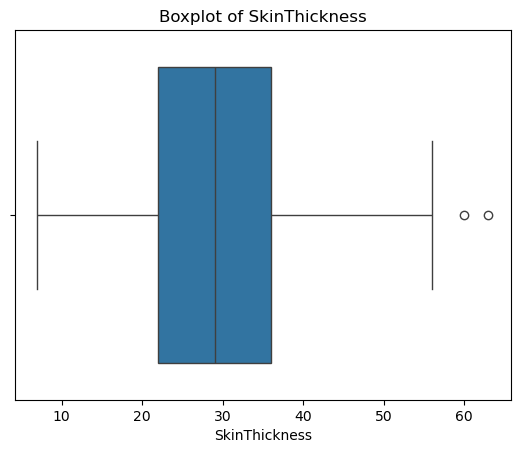

In [33]:
col='SkinThickness'
sns.boxplot(x=df[col])
plt.title(f"Boxplot of {col}")
plt.show()


**Outliers in SkinThickness:** Several values are 0 and 1 value is 100 and these are erros so i removed those values.

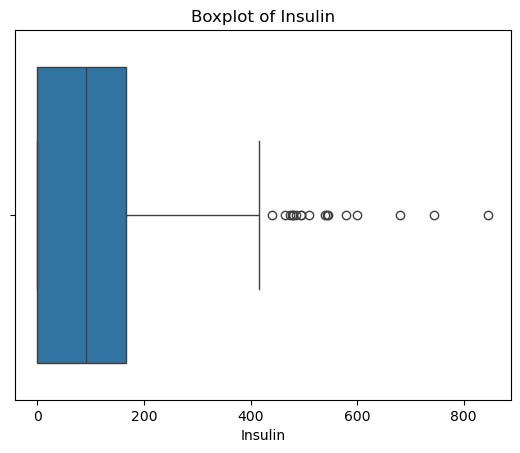

IQR: 166.0


In [34]:
col='Insulin'
sns.boxplot(x=df[col])
plt.title(f"Boxplot of {col}")
plt.show()

# IQR Calculation
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

print("IQR:", IQR)

In [35]:
(df['Insulin']==0).sum()

np.int64(140)

In [36]:
# alot of 0 values indicate that data is missing so we replaced that with null values.
df['Insulin']=df['Insulin'].replace(0,np.nan)

In [37]:
# Filled null values with median
df['Insulin'].fillna(df['Insulin'].median(),inplace=True)

C:\Users\91996\AppData\Local\Temp\ipykernel_26216\3140507370.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Insulin'].fillna(df['Insulin'].median(),inplace=True)


In [38]:
df.shape

(529, 9)

In [39]:
# Dealing with Outliers with clip
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower= Q1-1.5*IQR
upper= Q3+1.5*IQR

df['Insulin']=df['Insulin'].clip(lower,upper)

In [40]:
df['Insulin'].max()

274.0

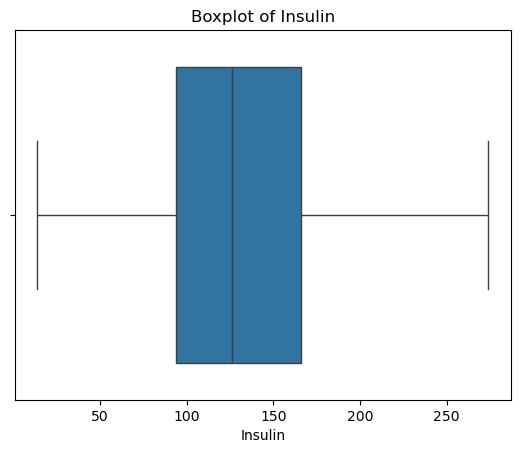

IQR: 72.0


In [41]:
col='Insulin'
sns.boxplot(x=df[col])
plt.title(f"Boxplot of {col}")
plt.show()

# IQR Calculation
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

print("IQR:", IQR)

**Outliers in Insulin:** There are 0 values which was error so i filled that with median and i have used Clip method to bring data in a range between lower and upper whiskers which removes outliers.


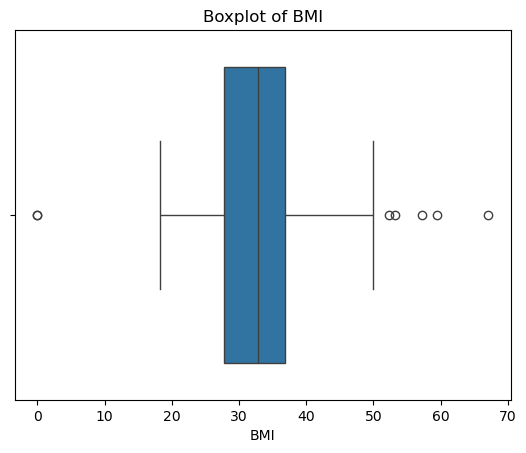

IQR: 8.999999999999996


In [42]:
col='BMI'
sns.boxplot(x=df[col])
plt.title(f"Boxplot of {col}")
plt.show()

# IQR Calculation
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

print("IQR:", IQR)

In [43]:
(df['BMI']==0).sum()

np.int64(2)

In [44]:
df['BMI']=df['BMI'].replace(0,np.nan)

In [45]:
# Filled null values with median
df['BMI'].fillna(df['BMI'].median(),inplace=True)

C:\Users\91996\AppData\Local\Temp\ipykernel_26216\2473063176.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['BMI'].fillna(df['BMI'].median(),inplace=True)


In [46]:
(df['BMI']>52).sum()

np.int64(5)

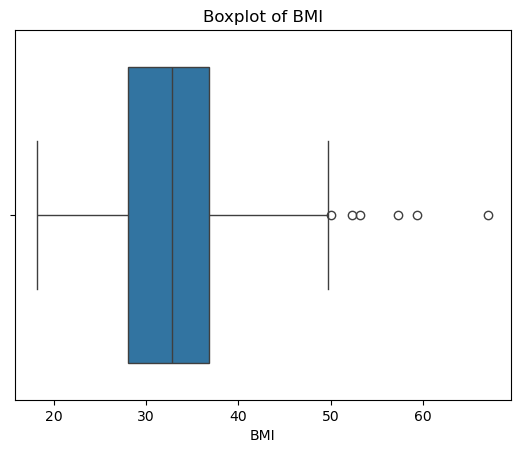

In [47]:
col='BMI'
sns.boxplot(x=df[col])
plt.title(f"Boxplot of {col}")
plt.show()

**Outliers in BMI:** In BMI 0 values are not possible so i replaced that with median and there are ouliers in range from 52 to 70 which is rare but can be possible so i kept that as it is.

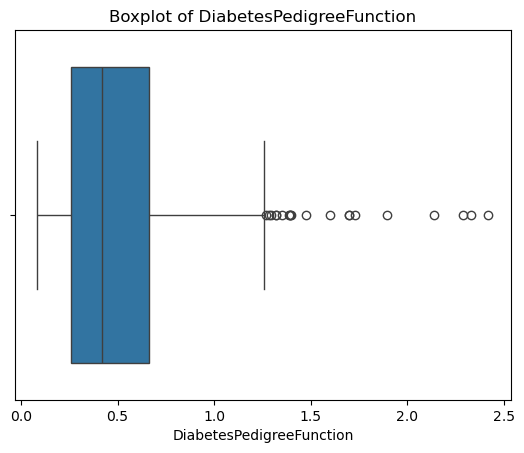

IQR: 0.402


In [48]:
col='DiabetesPedigreeFunction'
sns.boxplot(x=df[col])
plt.title(f"Boxplot of {col}")
plt.show()

# IQR Calculation
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

print("IQR:", IQR)

**Outliers in DiabetesPedigreeFunction:** These outliers were medically valid extreame cases not data erros that's why i kept them as it is.

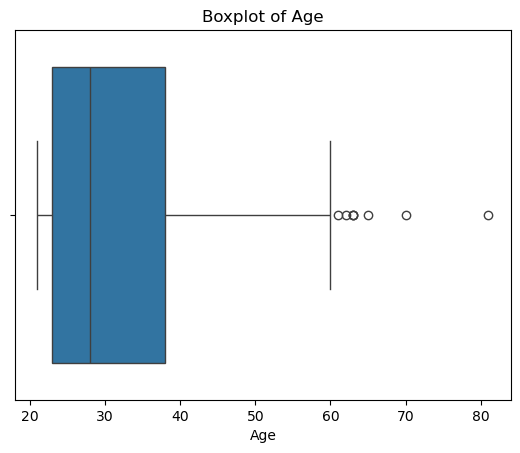

IQR: 15.0


In [49]:
col='Age'
sns.boxplot(x=df[col])
plt.title(f"Boxplot of {col}")
plt.show()

# IQR Calculation
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

print("IQR:", IQR)

**Outliers in Age:** extream values in age column is totally valid so i kepts them as it is

**Bivariate analysis:** it is done to understand the relationship between two variables, especially between features and the target. here we have all the numerical columns with binary target column so we will create boxplot to compare numerical features across the binary target variable

<Axes: xlabel='Outcome', ylabel='Glucose'>

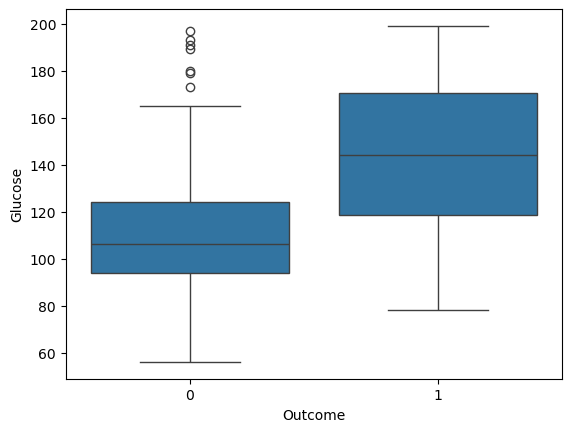

In [50]:
sns.boxplot(x="Outcome", y="Glucose", data=df)

**Relationship between glucose and outcome:** The boxplot shows that the median glucose level is significantly higher for diabetic patients (Outcome = 1) compared to non-diabetic patients (Outcome = 0). This indicates that glucose is a strong predictor of diabetes.

<Axes: xlabel='Outcome', ylabel='Pregnancies'>

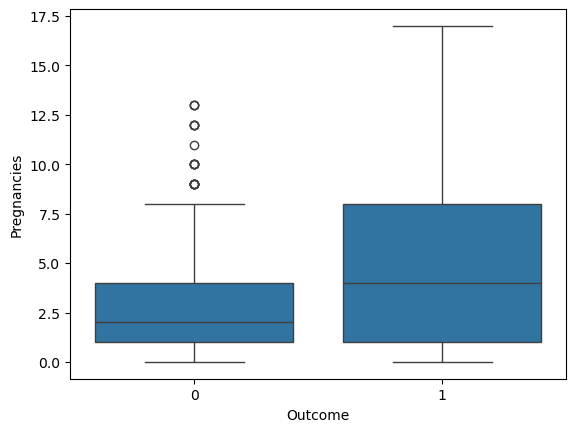

In [51]:
sns.boxplot(x="Outcome", y="Pregnancies", data=df)

**Relationship between pregnancies and outcome:** Medians are close and there are overlapping of plots which shows that there is weak relationship between pregnancies and outcome.

<Axes: xlabel='Outcome', ylabel='BloodPressure'>

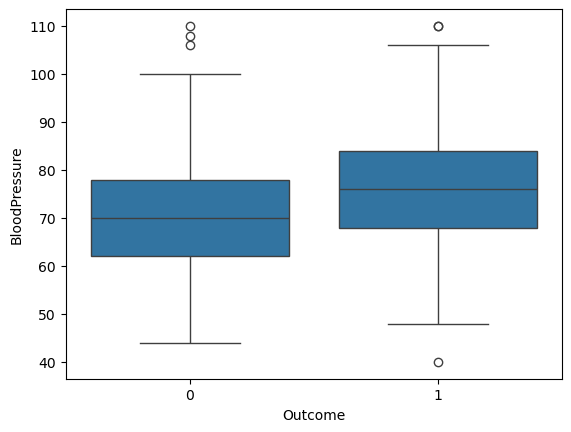

In [52]:
sns.boxplot(x='Outcome',y='BloodPressure', data=df)


**Relationship between blood pressure and outcome:** Blood pressure is not a good predictor for diabetes as the meadian difference is very close and graph is overlapping.

<Axes: xlabel='Outcome', ylabel='SkinThickness'>

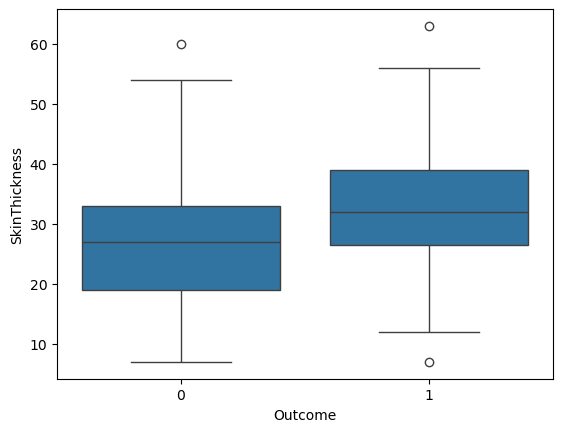

In [53]:
sns.boxplot(x='Outcome',y='SkinThickness', data=df)

**Relationship between SkinThickness and outcome:** SkinThickness is also a weak predictor as median range of both column is close and there is overlapping.

<Axes: xlabel='Outcome', ylabel='Insulin'>

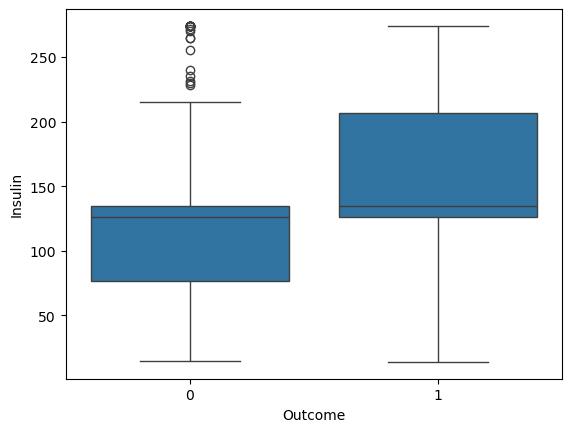

In [54]:
sns.boxplot(x='Outcome',y='Insulin', data=df)

**Relationship between Insulin and outcome:** Insulin is having moderate relationship as median spread is higher but there is overlapping.

<Axes: xlabel='Outcome', ylabel='BMI'>

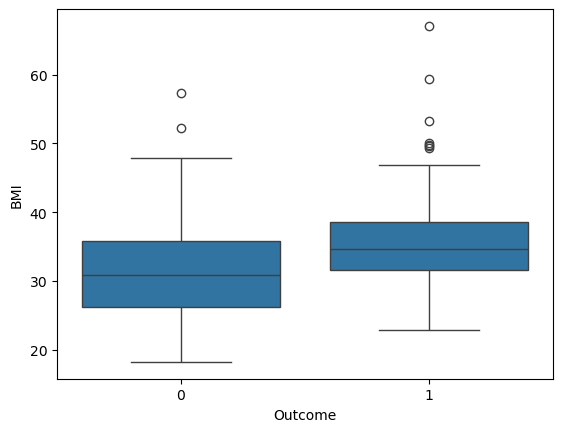

In [55]:
sns.boxplot(x='Outcome',y='BMI', data=df)

**Relationship between BMI and outcome:** Median spread is close and overlapping shows that BMI is not a good predictor alone.

<Axes: xlabel='Outcome', ylabel='DiabetesPedigreeFunction'>

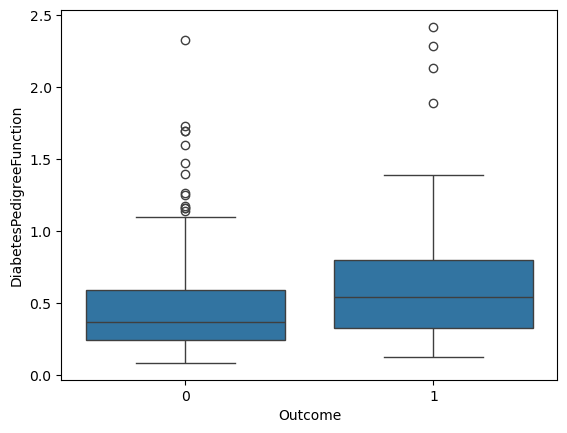

In [56]:
sns.boxplot(x='Outcome',y='DiabetesPedigreeFunction', data=df)

**Relationship between DiabetesPedigreeFunction and outcome:** it is also having overlapping and spread of medain is also very close so its not a good predictor.

<Axes: xlabel='Outcome', ylabel='Age'>

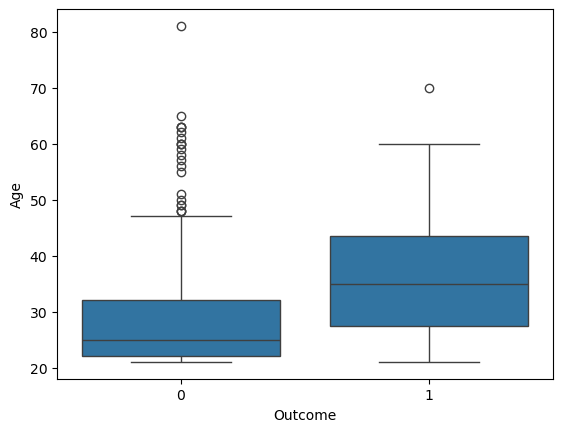

In [57]:
sns.boxplot(x='Outcome',y='Age', data=df)

**Relationship between Age and outcome:** Median spread is higher but overlapping is present so age is not a good predictor alone.

**Correlation Matrix:** showing relationship strength between all numerical variables.

In [58]:
corr_matrix= df.corr()
corr_matrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.125493,0.194535,0.108233,0.089143,0.012726,-0.001444,0.649231,0.256791
Glucose,0.125493,1.000000,0.210244,0.208611,0.538222,0.257224,0.162533,0.268000,0.504298
BloodPressure,0.194535,0.210244,1.000000,0.250773,0.091465,0.344570,-0.002457,0.353707,0.188993
SkinThickness,0.108233,0.208611,0.250773,1.000000,0.182719,0.670197,0.117408,0.133354,0.246183
Insulin,0.089143,0.538222,0.091465,0.182719,1.000000,0.245323,0.115178,0.188136,0.302296
BMI,0.012726,0.257224,0.344570,0.670197,0.245323,1.000000,0.153773,0.073664,0.296323
DiabetesPedigreeFunction,-0.001444,0.162533,-0.002457,0.117408,0.115178,0.153773,1.000000,0.063595,0.224723
Age,0.649231,0.268000,0.353707,0.133354,0.188136,0.073664,0.063595,1.000000,0.313297
Outcome,0.256791,0.504298,0.188993,0.246183,0.302296,0.296323,0.224723,0.313297,1.000000


Glucose shows the highest correlation (0.504) with Outcome, indicating a moderately strong positive relationship. Other variables such as Age, Insulin, and BMI show moderate relationships, while remaining variables have weak correlations.

**Correlation Matrix Heatmap**

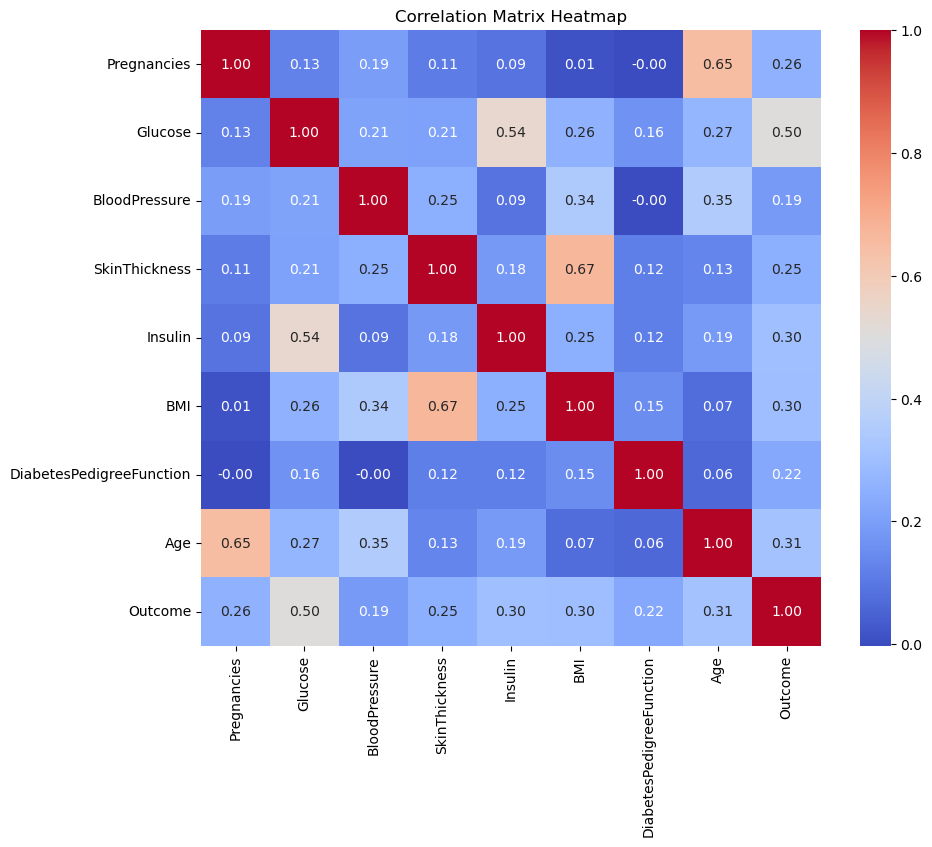

In [59]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(), 
    annot=True,        # Show correlation values
    cmap="coolwarm",   # Color style
    fmt=".2f"          # Show 2 decimal places
)

plt.title("Correlation Matrix Heatmap")
plt.show()

**Patterns and trends** The analysis shows that Glucose has the strongest positive relationship with Outcome. Age, BMI, and Insulin show moderate relationships. SkinThickness and BMI are moderately correlated with each other.

**Summary of Exploratory Data Analysis:** It revealed that Glucose is the most significant predictor of diabetes with moderate positive correlation (0.50). Age, BMI, and Insulin also show moderate relationships with the target variable. No severe multicollinearity was detected among independent variables. The dataset is suitable for logistic regression modeling after feature scaling.

**2. Data Preprocessing:**

In [60]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [63]:
#Feature & Target Separation
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [64]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [65]:
#Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


**3. Model Building:**

In [66]:
from sklearn.linear_model import LogisticRegression

In [67]:
#Create Model
model = LogisticRegression()

In [68]:
#Train the Model
model.fit(X_train, y_train)

LogisticRegression()

In [69]:
#Make Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

**4. Model Evaluation:**

In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [71]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8018867924528302


**Accuracy:** accuracy is how many total predictions model got correct out of all cases. So my model correctly predicted about 80% cases overall.

In [72]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.7142857142857143


**Precision:** precision is out of all cases the model predicted as positive, how many are truly positive. My model got 71% precision.

In [73]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.6060606060606061


**Recall:** recall is out of all truly positive cases, how many your model correctly detected. My model got 61% recall.

In [74]:
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)

F1-score: 0.6557377049180327


**F1-score:** A single score that shows the balance between precision and recall. My model have f1-score of 65%.

In [75]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8480697384806973


**ROC-AUC Score:** A score that shows how well the model can separate the two classes overall. My model have 85% ROC-AUC Score.

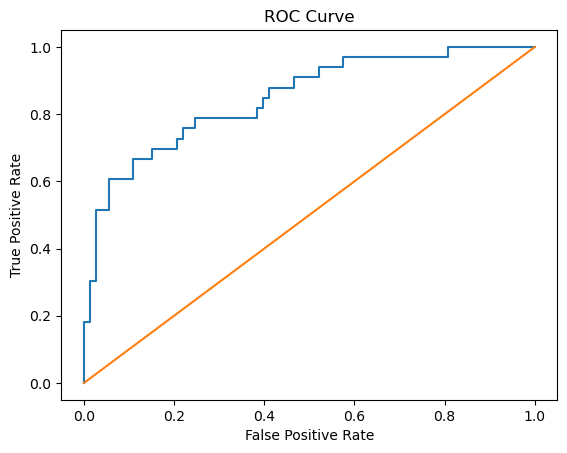

In [76]:
#ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

**ROC Curve:** The orange diagonal line shows random guessing performance, while the blue curve shows model's performance. Since the blue curve stays above the orange line, Model is better than random and learning useful patterns.

**5. Interpretation:**

**Coefficients of the logistic regression model:** I have compared each feature with outcome and understood that Glucose shows the highest correlation (0.504) with Outcome, indicating a moderately strong positive relationship. Other variables such as Age with 0.3, Insulin with 0.3, and BMI with 0.29 show moderate relationships, while remaining variables have weak correlations.

**Feature significance:** Positive coefficients - increase survival probability and features with larger absolute coefficients (positive or negative) influence the target more strongly. Since glucose shows the highes positive correlation.

**Save the Model**

In [78]:
import joblib

In [79]:
joblib.dump(model,"diabetes_model.pkl")

['diabetes_model.pkl']

In [80]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [81]:
import os
os.listdir()

['.ipynb_checkpoints',
 'Assignment_8.ipynb',
 'diabetes.csv',
 'diabetes_model.pkl',
 'ketto-clone-master2',
 'scaler.pkl']

In [82]:
loaded_model=joblib.load("diabetes_model.pkl")

In [83]:
loaded_model.predict(X_test[:5])

array([1, 0, 1, 0, 0])